# Single-dataset: Gene-Gene Covariation Analysis

This example demonstrates how to identify **cross-cell gene-gene covariation** —
gene pairs where one gene is expressed in the anchor cell and the other in a neighboring
motif cell, and their expression levels are significantly correlated specifically in
the spatial context of a given motif.

This analysis reveals potential intercellular signaling relationships: for example,
a ligand in one cell type co-varying with a receptor in a neighboring cell type.

**Dataset:** seqFISH mouse organogenesis E8.5 embryo (17,806 cells × 351 genes)

**Key API:**
- `spatial_query.compute_gene_gene_correlation` — pools all non-anchor motif cell types together
- `spatial_query.compute_gene_gene_correlation_by_type` — tests each non-anchor cell type separately
- `spatial_query.plot_gene_pair_heatmap` — visualize covarying gene modules

## Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import anndata as ad
import matplotlib.pyplot as plt

from SpatialQuery import spatial_query

## Load Data & Initialize

In [3]:
DATA_DIR = "../data/mouse_organogenesis"

adata = ad.read_h5ad(f"{DATA_DIR}/embryo1.h5ad")
adata

AnnData object with n_obs × n_vars = 17806 × 351
    obs: 'embryo', 'pos', 'z', 'x_global', 'y_global', 'x_global_affine', 'y_global_affine', 'embryo_pos', 'embryo_pos_z', 'Area', 'UMAP1', 'UMAP2', 'celltype_mapped_refined', 'segmentation_vertices_x_global_affine', 'segmentation_vertices_y_global_affine'
    var: 'gene'
    uns: 'celltype_mapped_refined_colors'
    obsm: 'X_spatial', 'X_umap'

Inspect `adata.obsm` for spatial coordinates, `adata.obs` for cell type labels, and `adata.var` for gene names. Then set the corresponding column names below.

In [4]:
spatial_key = "X_spatial"
label_key = "celltype_mapped_refined"
feature_name = "gene"
dataset_name = "mouse_embryo1"

In [5]:
sp = spatial_query(
    adata=adata,
    dataset=dataset_name,
    spatial_key=spatial_key,
    label_key=label_key,
    feature_name=feature_name,
    build_gene_index=False,
    if_lognorm=True,
    if_normalize_spatial_coord=True,
)


Auto-normalizing spatial coordinates: mean nearest neighbor distance = 1.0
Scale factor: 51.7200
build_gene_index is False. Using adata.X for gene expression analysis.
Log normalizing the expression data... If data is already log normalized, please set if_lognorm to False.


## Method 1: Pooled Covariation (`compute_gene_gene_correlation`)

`compute_gene_gene_correlation` **pools all non-anchor cell types** in the motif into a
single neighbor group before computing correlations. For each (anchor gene, neighbor gene) pair,
it performs two statistical tests:

1. **Test 1 (spatial specificity):** Is the correlation between motif-positive anchor–neighbor
   pairs significantly higher than between randomly paired cells of the same types?
2. **Test 2 (motif specificity):** Is the correlation between motif-positive anchor–neighbor
   pairs significantly higher than between motif-negative anchor cells and their neighbors?

Only gene pairs passing **both** tests (FDR < 0.05) are reported as significant.

**Key parameters:**

| Parameter | Description |
|-----------|-------------|
| `ct` | Anchor cell type |
| `motif` | List of neighbor cell types forming the motif |
| `max_dist` | Neighborhood radius (use either `max_dist` or `k`) |
| `k` | Number of nearest neighbors (use either `max_dist` or `k`) |
| `min_nonzero` | Minimum non-zero expression values required to include a gene |

**Key output columns:**

| Column | Description |
|--------|-------------|
| `gene_center` | Gene expressed in the anchor cell |
| `gene_motif` | Gene expressed in the neighbor cell |
| `corr_neighbor` | Correlation between motif+ anchor–neighbor pairs |
| `corr_non_neighbor` | Correlation between randomly paired cells (Test 1 baseline) |
| `corr_center_no_motif` | Correlation for motif− anchors (Test 2 baseline) |
| `combined_score` | Combined effect size from both tests |
| `if_significant` | Whether the pair passes both FDR-corrected tests |

> **Note:** `compute_gene_gene_correlation_by_type` and `compute_gene_gene_correlation` use distance-based neighborhoods when specifying `max_dist` and KNN-defined neighborhoods when specifying `k`.

In [6]:
anchor_ct = "Gut tube"
motif = ["Splanchnic mesoderm", "Endothelium"]
max_dist = 8

covarying_pooled, cell_ids = sp.compute_gene_gene_correlation(
    ct=anchor_ct,
    motif=motif,
    max_dist=max_dist,
)

# Filter to significant pairs
covarying_pooled_sig = covarying_pooled[covarying_pooled["if_significant"]].copy()
print(f"Total gene pairs tested: {len(covarying_pooled)}")
print(f"Significant covarying pairs (pooled): {len(covarying_pooled_sig)}")
covarying_pooled_sig.head(10)

Computing covarying genes using expression data...
After filtering (min_nonzero=10): 351 genes

Computing Correlation 1: Center with motif vs Neighboring motif (paired)
Number of pairs: 4111
Unique center cells: 322
Unique neighbor cells: 483
Effective sample size: 322
... (32 lines omitted) ...
Total gene pairs tested: 100401
Significant covarying pairs (pooled): 131


,gene_center,gene_motif,corr_neighbor,corr_non_neighbor,p_value_test1,delta_corr_test1,corr_center_no_motif,p_value_test2,delta_corr_test2,combined_score,q_value_test1,q_value_test2,reject_test1_fdr,reject_test2_fdr,abs_combined_score,if_significant
0,Sp5,Tbx5,0.655305,-0.002355,0.000000e+00,0.657660,0.076782,0.000000e+00,0.578523,180.679125,0.000000e+00,0.000000e+00,True,True,180.679125,True
1,Hoxb1,Tbx1,0.509674,-0.009432,5.182521e-13,0.519105,0.063244,4.218847e-15,0.446430,6.405376,8.672172e-09,2.117883e-10,True,True,6.405376,True
2,Hoxb1,Nr2f1,-0.476778,0.012423,1.958722e-11,-0.489201,-0.026895,1.021405e-14,-0.449883,-5.977464,1.638814e-07,3.418337e-10,True,True,5.977464,True
3,Sp5,Wnt2,0.550858,0.000576,5.329071e-15,0.550282,0.150484,1.820766e-13,0.400374,5.926777,2.140176e-10,3.749767e-09,True,True,5.926777,True
5,Cdx2,Hoxd4,0.540384,-0.000797,2.065015e-14,0.541180,0.163879,4.823031e-12,0.376505,5.204375,5.183239e-10,5.097233e-08,True,True,5.204375,True
6,Sp5,Aldh1a2,0.480698,-0.000410,3.553646e-11,0.481108,0.079942,2.936762e-12,0.400756,4.743279,2.642886e-07,3.685673e-08,True,True,4.743279,True
7,Sp5,Wnt2b,0.469923,-0.000968,1.097769e-10,0.470892,0.068457,3.827383e-12,0.401466,4.615457,7.601177e-07,4.520860e-08,True,True,4.615457,True
8,Sox4,Col1a1,-0.354447,0.008312,1.714930e-06,-0.362759,0.093171,2.915446e-13,-0.447618,-4.555193,1.748027e-03,5.322067e-09,True,True,4.555193,True
9,Cpm,Tbx5,0.400801,0.002186,9.562441e-08,0.398615,-0.025164,1.494582e-12,0.425965,4.365485,1.812396e-04,2.143679e-08,True,True,4.365485,True
10,Bambi,Hand2,0.372506,0.000139,7.792992e-07,0.372367,-0.061155,1.088241e-12,0.433661,4.313963,9.536025e-04,1.680930e-08,True,True,4.313963,True


### Top Frequent Genes in Covarying Pairs (Pooled)

Visualize the top 20 most frequently appearing genes on the anchor side (`gene_center`)
and the motif side (`gene_motif`) among significant covarying pairs.

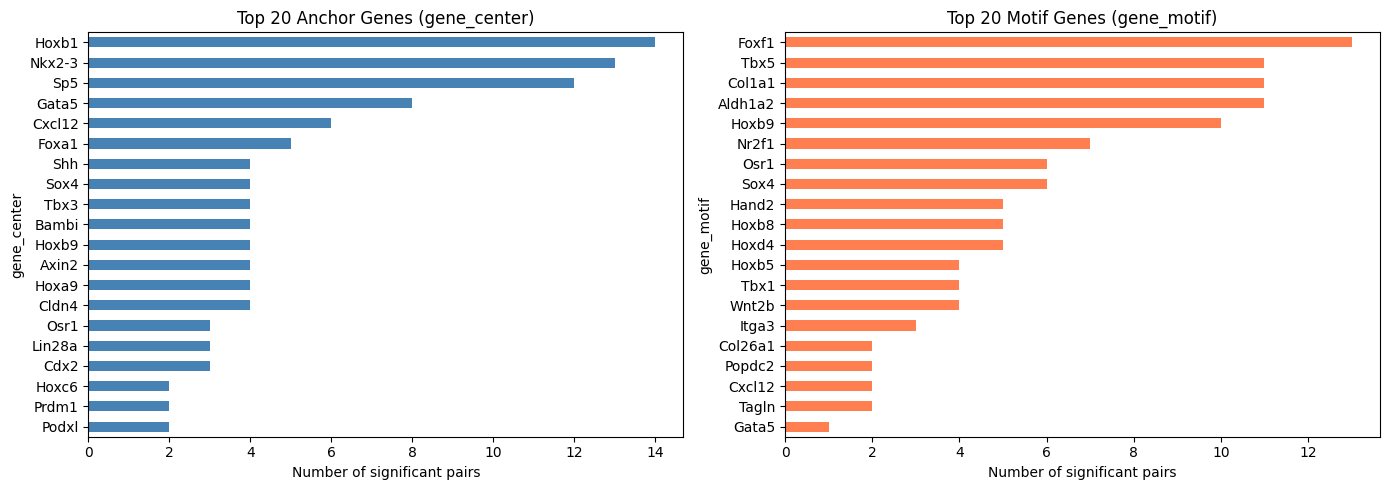

In [7]:
top_n = 20

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

covarying_pooled_sig["gene_center"].value_counts().head(top_n).plot.barh(
    ax=axes[0], color="steelblue")
axes[0].set_title(f"Top {top_n} Anchor Genes (gene_center)")
axes[0].set_xlabel("Number of significant pairs")
axes[0].invert_yaxis()

covarying_pooled_sig["gene_motif"].value_counts().head(top_n).plot.barh(
    ax=axes[1], color="coral")
axes[1].set_title(f"Top {top_n} Motif Genes (gene_motif)")
axes[1].set_xlabel("Number of significant pairs")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## Method 2: Per-cell-type Covariation (`compute_gene_gene_correlation_by_type`)

`compute_gene_gene_correlation_by_type` tests gene-gene correlation **separately for each
non-anchor cell type** in the motif. This is useful when the motif contains multiple cell
types and you want to know which specific cell type drives the covariation.

It performs the same two statistical tests as the pooled version, but stratified by neighbor
cell type. The output includes an additional `cell_type` column indicating which neighbor
type each gene pair belongs to.

**Key parameters:**

| Parameter | Description |
|-----------|-------------|
| `ct` | Anchor cell type |
| `motif` | List of neighbor cell types forming the motif |
| `max_dist` | Neighborhood radius |
| `min_nonzero` | Minimum non-zero expression values required to include a gene |

**Key output columns:**

| Column | Description |
|--------|-------------|
| `cell_type` | The neighbor cell type in the pair |
| `gene_center` | Gene expressed in the anchor cell |
| `gene_motif` | Gene expressed in the neighbor cell |
| `corr_neighbor` | Correlation between motif+ anchor–neighbor pairs |
| `corr_non_neighbor` | Correlation between randomly paired cells (Test 1 baseline) |
| `corr_center_no_motif` | Correlation for motif− anchors (Test 2 baseline) |
| `combined_score` | Combined effect size from both tests |
| `if_significant` | Whether the pair passes both FDR-corrected tests |

> **Note on equivalence:** Because covariation is computed between the **anchor type** and
> **non-anchor types in the motif**, when the motif contains only **one non-anchor cell type**,
> `compute_gene_gene_correlation` and `compute_gene_gene_correlation_by_type` produce
> equivalent results.

In [8]:
anchor_ct = "Gut tube"
motif = ["Splanchnic mesoderm", "Endothelium"]
max_dist = 8

covarying = sp.compute_gene_gene_correlation_by_type(
    ct=anchor_ct,
    motif=motif,
    max_dist=max_dist,
)

# Filter to significant pairs
covarying_sig = covarying[covarying["if_significant"]].copy()
print(f"Total gene pairs tested: {len(covarying)}")
print(f"Significant covarying pairs: {len(covarying_sig)}")
covarying_sig.head(10)

Computing covarying genes using expression data...
Analyzing 2 non-center cell types in motif: ['Splanchnic mesoderm', 'Endothelium']
After filtering (min_nonzero=10): 351 genes

Computing Correlation-3: Center without motif vs Neighbors
Unique center cells: 1106
Unique neighbor cells: 2851
... (57 lines omitted) ...
Total gene pairs tested: 208202
Significant covarying pairs: 411


,cell_type,gene_center,gene_motif,corr_neighbor,corr_non_neighbor,p_value_test1,delta_corr_test1,corr_center_no_motif,p_value_test2,delta_corr_test2,combined_score,q_value_test1,q_value_test2,reject_test1_fdr,reject_test2_fdr,abs_combined_score,if_significant
0,Splanchnic mesoderm,Sp5,Tbx5,0.696998,-0.004279,0.000000e+00,0.701277,0.076782,0.0,0.620216,193.360220,0.000000e+00,0.0,True,True,193.360220,True
1,Splanchnic mesoderm,Nkx2-3,Tagln,0.576550,-0.006229,0.000000e+00,0.582779,-0.047309,0.0,0.623860,183.460727,0.000000e+00,0.0,True,True,183.460727,True
2,Splanchnic mesoderm,Hoxb1,Tbx1,0.606402,-0.030189,0.000000e+00,0.636591,0.063244,0.0,0.543158,171.356423,0.000000e+00,0.0,True,True,171.356423,True
3,Splanchnic mesoderm,Sp5,Wnt2,0.596063,0.000067,0.000000e+00,0.595996,0.150484,0.0,0.445579,147.211285,0.000000e+00,0.0,True,True,147.211285,True
4,Splanchnic mesoderm,Tbx3,Tagln,0.395296,-0.000074,1.286408e-07,0.395370,-0.165390,0.0,0.560686,118.561425,1.580134e-04,0.0,True,True,118.561425,True
5,Splanchnic mesoderm,Nkx2-3,Tbx1,0.472840,-0.021198,1.421219e-11,0.494038,-0.059121,0.0,0.531961,113.319516,6.649451e-08,0.0,True,True,113.319516,True
7,Splanchnic mesoderm,Hoxb1,Hand2,0.535514,0.008616,9.947598e-14,0.526897,0.010838,0.0,0.524676,112.237171,9.414136e-10,0.0,True,True,112.237171,True
8,Splanchnic mesoderm,Hoxb1,Nr2f1,-0.541454,0.013023,5.329071e-15,-0.554477,-0.026895,0.0,-0.514559,-110.431632,6.724383e-11,0.0,True,True,110.431632,True
9,Splanchnic mesoderm,Bambi,Hand2,0.454222,0.000136,6.141634e-10,0.454087,-0.061155,0.0,0.515377,109.484039,1.816904e-06,0.0,True,True,109.484039,True
10,Splanchnic mesoderm,Sox4,Col1a1,-0.423106,0.008016,6.514124e-09,-0.431122,0.093171,0.0,-0.516277,-109.476893,1.244269e-05,0.0,True,True,109.476893,True


## Summary by Neighbor Cell Type

Check how many significant pairs are found for each neighbor cell type.

In [9]:
covarying_sig["cell_type"].value_counts()

cell_type
Splanchnic mesoderm    382
Endothelium             29
Name: count, dtype: int64

### Top Frequent Genes in Covarying Pairs (Per Cell Type)

For `compute_gene_gene_correlation_by_type`, visualize the top 20 genes
separately for each neighbor cell type.


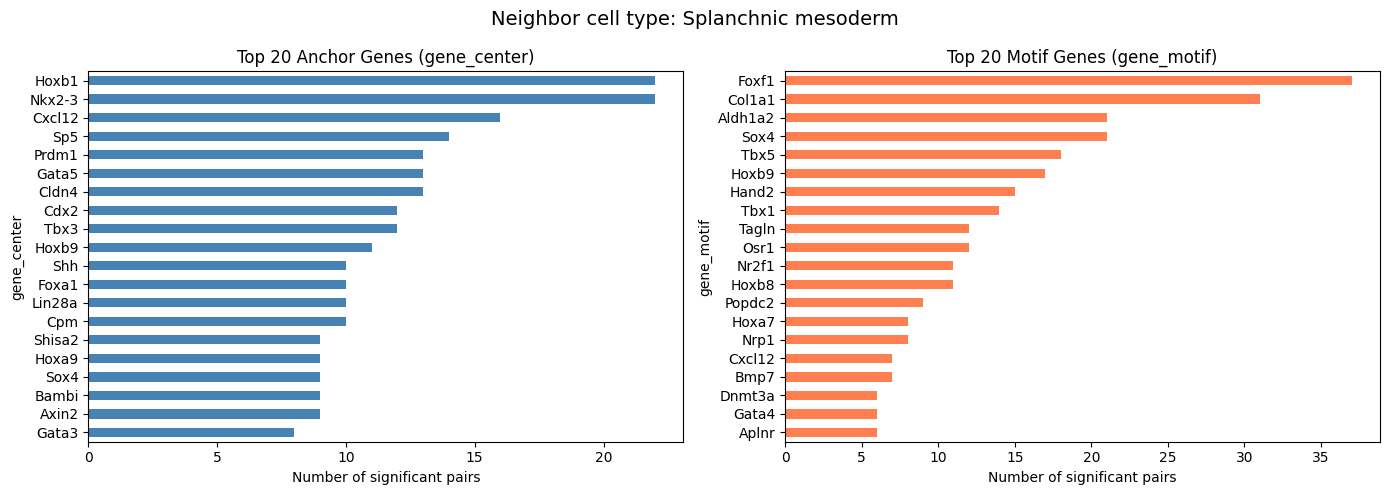

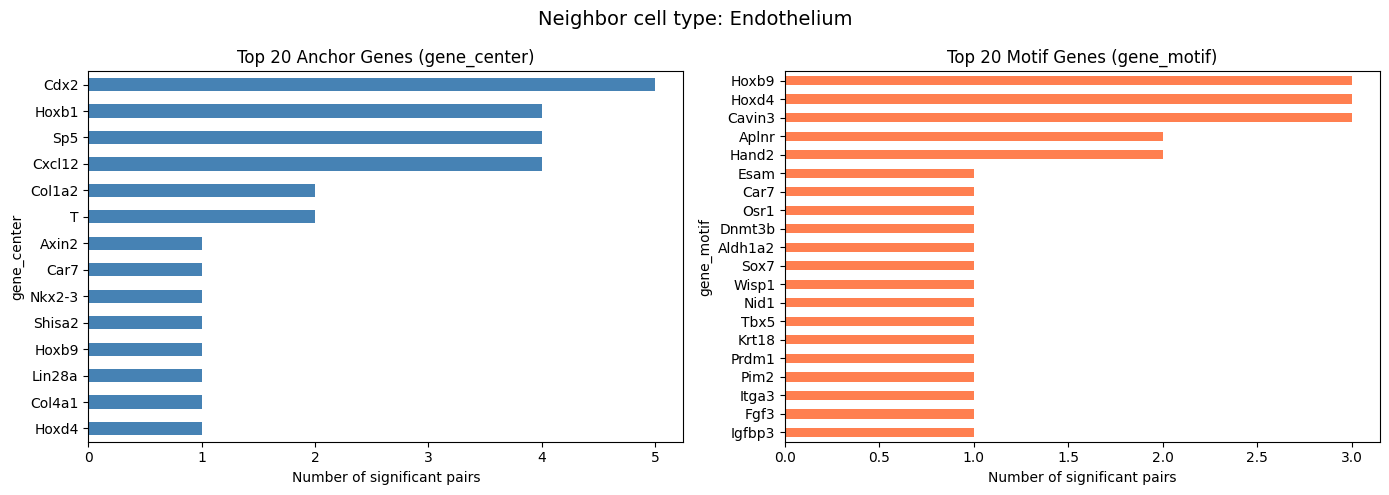

In [10]:
top_n = 20
cell_types = covarying_sig["cell_type"].unique()

for ct in cell_types:
    ct_df = covarying_sig[covarying_sig["cell_type"] == ct]
    if len(ct_df) == 0:
        continue

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Neighbor cell type: {ct}", fontsize=14)

    ct_df["gene_center"].value_counts().head(top_n).plot.barh(
        ax=axes[0], color="steelblue")
    axes[0].set_title(f"Top {top_n} Anchor Genes (gene_center)")
    axes[0].set_xlabel("Number of significant pairs")
    axes[0].invert_yaxis()

    ct_df["gene_motif"].value_counts().head(top_n).plot.barh(
        ax=axes[1], color="coral")
    axes[1].set_title(f"Top {top_n} Motif Genes (gene_motif)")
    axes[1].set_xlabel("Number of significant pairs")
    axes[1].invert_yaxis()

    plt.tight_layout()
    plt.show()


## Visualize Covarying Gene Modules

`plot_gene_pair_heatmap` clusters the significant gene pairs into modules using hierarchical
clustering, revealing groups of co-regulated gene pairs. The heatmap shows the combined score
(effect size) for each pair, with rows and columns reordered by cluster membership.

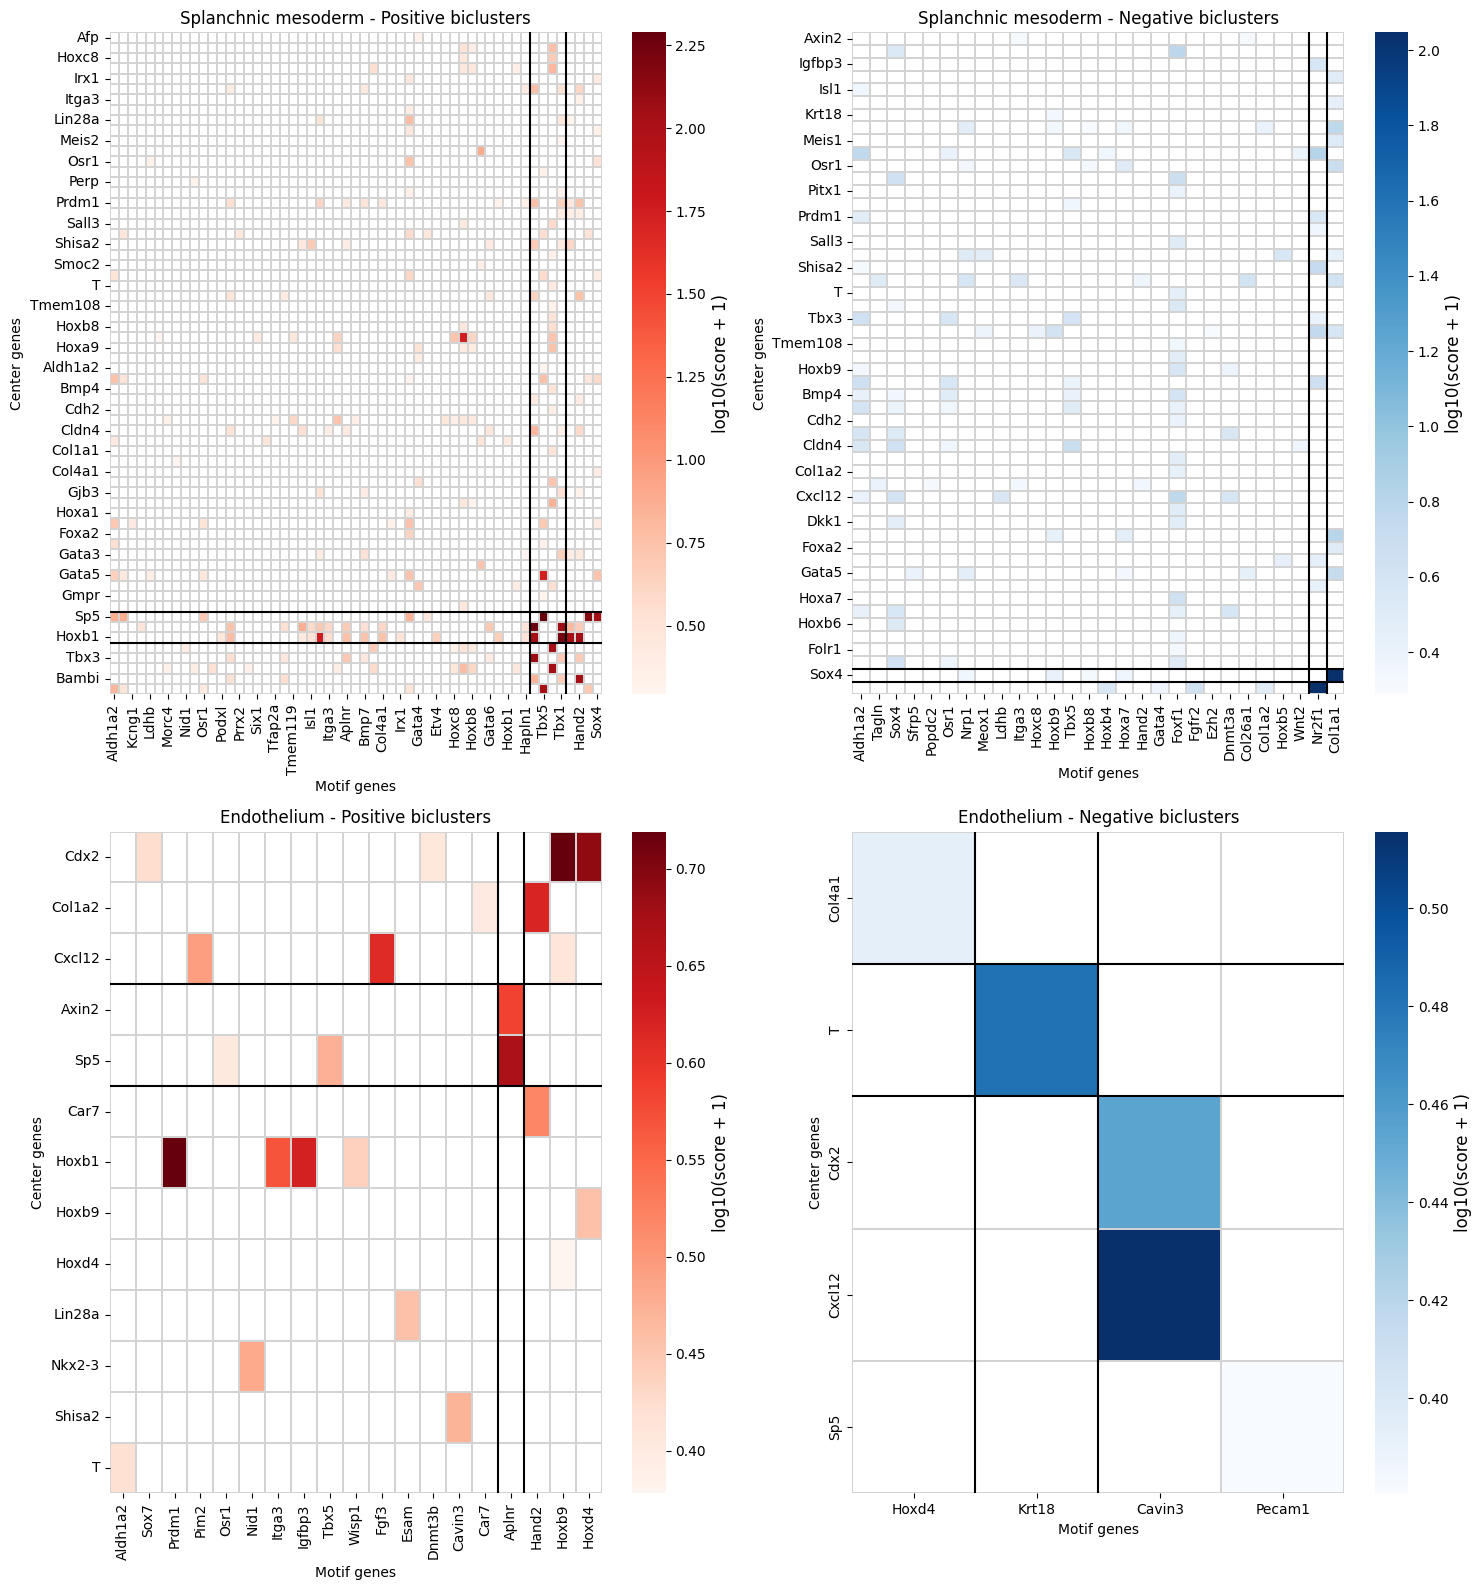

In [11]:
modules = sp.plot_gene_pair_heatmap(
    gene_pair_df=covarying_sig,
    figsize=(15, 8),
)

## Explore Gene Modules

The returned DataFrame adds cluster assignments (`cluster_row`, `cluster_col`, `cluster_type`)
to each gene pair, enabling downstream analysis of specific gene modules.

In [12]:
modules.head(10)

,gene_center,gene_motif,combined_score,cluster_type,cluster_row,cluster_col,cell_type
0,Afp,Gata4,1.131970,positive,0,0,Splanchnic mesoderm
1,Akr1c19,Gata4,1.507798,positive,0,0,Splanchnic mesoderm
2,Aldh1a2,Tbx5,1.037975,positive,0,1,Splanchnic mesoderm
3,Axin2,Aldh1a2,4.586966,positive,0,0,Splanchnic mesoderm
4,Axin2,Foxf1,1.081744,positive,0,0,Splanchnic mesoderm
5,Axin2,Osr1,2.077390,positive,0,0,Splanchnic mesoderm
6,Axin2,Sox4,2.845119,positive,0,2,Splanchnic mesoderm
7,Axin2,Tbx5,4.832735,positive,0,1,Splanchnic mesoderm
8,Axin2,Wnt2,1.783934,positive,0,2,Splanchnic mesoderm
9,Axin2,Wnt2b,2.215038,positive,0,0,Splanchnic mesoderm


In [13]:
# Count gene pairs per module
modules.groupby(["cell_type", "cluster_type"]).size().reset_index(name="n_pairs")

,cell_type,cluster_type,n_pairs
0,Endothelium,negative,5
1,Endothelium,positive,24
2,Splanchnic mesoderm,negative,134
3,Splanchnic mesoderm,positive,248
